## 音频分割类：AudioSlice

**初始化参数：**
- `sample_rate`: 音频采样率（`Audio Sample Rate`), 默认`3200Hz`
- `threshold`: 音量阈值(dB阈值)，音量小于这个值当静音处理，默认`-40`
- `min_length`: 分割的音频每段最小的长度,默认：`5000`单位毫秒
- `min_interval`: 最短切割间隔，每段最小的秒数，默认`300`毫秒
- `hop_size`: 窗口跳跃的样本数，怎么算音量曲线，越小精度越大，计算量越大（不是精度越大效果越好）:默认`20`
- `max_silence_keep`: 切完后静音最多留多长时间，单位毫秒，默认`2000`
- `alpha`: 默认`0.9`

In [1]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt

### 1. 编写音频分割类

In [2]:
class AudioSlice:
    def __init__(
            self,
            sample_rate: int = 3200,
            threshold: float = -40.0,
            min_length: int = 5000,
            min_interval: int = 300,
            hop_size: int = 20,
            max_silent_keep: int = 2000,
    ):
        # 注意最小长度是需要大于切割的最短间隔，大于hop_size的
        if not min_length >= min_interval >= hop_size:
            raise ValueError("Need min_length >= min_interval >= hop_size")

        if not max_silent_keep >= hop_size:
            raise ValueError("Need max_lilence_keep >= hop_size")

        # 最短切割间隔: 音频采样率 * 最短切割间隔(秒)
        # 最短切割，我们传递过来的是时间(毫秒),但是我们用这个的时候，我们只需要知道最小取多少条音频波形数组的数
        min_interval = round(sample_rate * min_interval / 1000)
        # 音频阈值：分贝转一个正数
        self.threshold = 10 ** (threshold / 20.0)
        # 音量曲线：越小精度越大，计算量也越大
        self.hop_size = round(sample_rate * hop_size / 1000)
        # 窗口大小：取最短切割间隔、4倍hop_size中的最小值
        self.window_size = min(min_interval, 4 * self.hop_size)
        # 分段最小的长度：
        self.min_length = round(sample_rate * min_length / 1000 / self.hop_size)
        # 最短切割间隔
        self.min_interval = round(min_interval / self.hop_size)
        # 静音最多保留时间
        self.max_silent_keep = round(sample_rate * max_silent_keep / 1000 / self.hop_size)

    def _apply_slice(self, waveform, begin, end):
        if len(waveform.shape) > 1:
            return waveform[
                   :, begin * self.hop_size: min(waveform.shape[1], end * self.hop_size)
                   ]
        else:
            return waveform[
                   begin * self.hop_size: min(waveform.shape[0], end * self.hop_size)
                   ]

    def get_rms(self, arr, frame_length=2048, hop_length=512, pad_mode="constant"):
        """
        这个函数的参考了librosa库中的类似功能
        RMS: Root Mean Square
        计算音频的均方根（RMS)能量：RMS能量是一种衡量音频信号强度的指标，通常用于音频处理和分析。
        参数说明：
        - arr: 输入音频信号，通常是一维`NumPy`数组
        - frame_length: 每个帧的长度，默认是2048
        - hop_length: 帧之间的跳跃长度，默认为512
        - pad_mode: 填充模式，默认为"constant"

        这个函数主要作用：
        - 对输入音频信号进行填充，使得每个帧的中心对齐音频信号的样本
        - 使用步幅技巧创建帧数组
        - 计算每个帧的功率，并返回RMS值
        这是音频信号处理中得一个常见操作，用于分析音频信号的能量分布。
        要理解这个函数：用s.get_rms(arr=np.array(range(1, 17)), frame_length=6, hop_length=4)输出相关的值就很直观的明白了
        理解了这个函数需要的目标arr新的view，其实换一种写法也很简单的
        """
        # 计算音频填充长度，使得每个帧的中心对齐音频信号的样本
        # frame_length: 就是一帧的长度，一帧有多少个数据值(音频数据是个一维的numpy数组)，我们给其左右各填充一半帧的长度
        # 后面得到的数据点数据：(frame_length, 数据点//hop_length)的二维数据
        # 然后计算-2维度的强度值(绝对值、平方、再平均值、再平方根)：最终得到个(数据点//hop_length,)行的数据
        padding = (int(frame_length // 2), int(frame_length // 2))
        # 使用`np.pad`函数对音频信号进行填充: 左右各填充半帧的数据(0)
        # 比如一帧有2048个数据，那么我们给其左右各填充1024个0
        arr = np.pad(arr, padding, mode=pad_mode)

        axis = -1  # 表示最后一个轴
        # 计算新的步幅，使得每个帧可以通过步幅技巧访问
        # strides：是一个数组内部布局紧密相关的概念，具体的说，它表示沿着数组的每一个维度从一个元素到下一个元素在内存中跳过的字节数
        # 假如(y是一维，32位的浮点数)那么y.strides的值是4, out_strides的值会是(4, 4)
        out_strides = arr.strides + tuple([arr.strides[axis]])

        # 调整形状以适应帧长度: y的形状会是：(N,), N是音频数据点的个数
        # 我们要生成一个新的数组：new_arr
        # x的修改过的形状，先让其等于y的shape：(N,)，list(arr.shape)那么就是：[N]
        x_shape_trimmed = list(arr.shape)
        # 注意：我们的y是填充了一帧的，那么我们的x，数据size是要减去一帧的长度的，由于下标从0开始还要减去1
        x_shape_trimmed[axis] -= frame_length - 1

        # 计算输出的形状: (源音频的数据点, 一帧的长度/数据点)
        out_shape = tuple(x_shape_trimmed) + tuple([frame_length])

        # 使用`np.lib.stride_tricks.as_strided`创建帧数组：无需复制数据，创建一个新的视图View
        # 基于y的数据，创建一个out_shape的形状，步长为out_strides的数据视图View:
        xw = np.lib.stride_tricks.as_strided(arr, shape=out_shape, strides=out_strides)

        # 调整轴位置：移动帧轴的位置，使得帧轴位于目标位置
        if axis < 0:
            target_axis = axis - 1
        else:
            target_axis = axis + 1
        # 2个维度换一下：以前的行，成为了列
        # xw.shape由(n, m)变成(m, n)
        # 比如：[[1,2,3], [4,5,6]]变成了：[[1,4],[2,5],[3,6]]
        xw = np.moveaxis(xw, -1, target_axis)

        # 下采样帧：创建切片对象以沿着跳跃长度下采样帧
        slices = [slice(None)] * xw.ndim
        # slice不是一个普通函数，而是一个内置的类型/类
        # slice表示一个切片操作，通常与序列类型的切片语法[start:stop:step]一起使用
        slices[axis] = slice(0, None, hop_length)
        # x的-1维度：会有 xw.shape[-1] // hop_length个数
        x = xw[tuple(slices)]

        # 计算功率：计算每个帧的功率（平方平均值）
        power = np.mean(np.abs(x) ** 2, axis=-2, keepdims=True)

        # 返回RMS值
        # 第1个值其实就是：np.sqrt(np.mean(np.abs(x[:,0]) ** 2))
        # 第2个值其实就是：np.sqrt(np.mean(np.abs(x[:,1]) ** 2))
        return np.sqrt(power)

    def slice(self, waveform):
        """
        根据音频信号强度分割音频
        :param waveform: 音频文件的波形数组，一般是一维的【处理单声道】
        :return:
        """
        if len(waveform.shape) > 1:
            # 多声道就去声道的平均值，这个好理解：人声和背景声，我们是做分割，知道个平均值就够了
            samples = waveform.mean(axis=0)
        else:
            samples = waveform

        # 如果音频数组小于最小长度，那么直接返回即可，无需分割
        if samples.shape[0] <= self.min_length:
            return [waveform]

        # 获取RMS
        rms_list = self.get_rms(arr=samples, frame_length=self.window_size, hop_length=self.hop_size).squeeze(0)

        # 静音tags
        silent_tags = []
        silent_start = None    # 静音开始的帧（低于阈值的帧）
        clip_start = 0         # 最开始裁剪的地方是从0号位置开始的

        for i, rms in enumerate(rms_list):
            # 遍历每一帧的信号强度
            if rms <= self.threshold:
                # 如果信号强度小于阈值，且静音开始是None那么就记录值
                if silent_start is None:
                    silent_start = i
                continue

            # 当前帧大于阈值，且已经记录了silent_start,继续进入下一帧
            if silent_start is None:
                continue

            # 如果间隔不够，或者i已经大于保持静音帧长度了，我们就设置is_leading_silent为True
            # 这里是配合后面的need_slice_middle来去掉前面那长长的静音段
            is_leading_silent = silent_start == 0 and i > self.max_silent_keep

            # 是否需要开始裁剪
            need_slice_middle = (
                    # 当前帧 - 静音开始的帧  > 最小间隔间隔
                    i - silent_start >= self.min_interval
                    # 同时还需要：当前帧 - 裁剪开始的位置  >= 裁剪最小长度（帧）传参是毫秒，但是计算的时候是得到采样数除以hop_size的
                    and i - clip_start >= self.min_length
            )

            # 如果前面音频静音很长，且不需要裁剪音频，咱们就重置一下静音开始位置为None
            # 这个代码其实只会处理前面的静音内容的
            if not is_leading_silent and not need_slice_middle:
                silent_start = None
                continue

            # Need slicing. Record the range of silent frames to be removed.
            # 需要分割了，记录要删除的无声帧的范围
            if i - silent_start <= self.max_silent_keep:
                # 得到音频信号强度最低的帧的下标
                pos = rms_list[silent_start: i + 1].argmin() + silent_start
                if silent_start == 0:
                    silent_tags.append((0, pos))
                else:
                    silent_tags.append((pos, pos))
                clip_start = pos
            elif i - silent_start <= self.max_silent_keep * 2:
                pos = rms_list[
                      i - self.max_silent_keep: silent_start + self.max_silent_keep + 1
                      ].argmin()
                pos += i - self.max_silent_keep

                pos_l = (
                        rms_list[
                        silent_start: silent_start + self.max_silent_keep + 1
                        ].argmin()
                        + silent_start
                )
                pos_r = (
                        rms_list[i - self.max_silent_keep: i + 1].argmin()
                        + i
                        - self.max_silent_keep
                )
                if silent_start == 0:
                    silent_tags.append((0, pos_r))
                    clip_start = pos_r
                else:
                    silent_tags.append((min(pos_l, pos), max(pos_r, pos)))
                    clip_start = max(pos_r, pos)
            else:
                pos_l = (
                        rms_list[
                        silent_start: silent_start + self.max_silent_keep + 1
                        ].argmin()
                        + silent_start
                )
                pos_r = (
                        rms_list[i - self.max_silent_keep: i + 1].argmin()
                        + i
                        - self.max_silent_keep
                )
                if silent_start == 0:
                    silent_tags.append((0, pos_r))
                else:
                    silent_tags.append((pos_l, pos_r))
                clip_start = pos_r

            # 把静音的起始位置设置为None
            silent_start = None

        # for循环结束
        # 现获取到所有的帧数
        total_frames = rms_list.shape[0]

        if silent_start is not None and total_frames - silent_start >= self.min_interval:
            # 如果无声帧非None，且从无声帧到最后的帧长度大于最低长度要求，那么就再加一个silence_tag
            silence_end = min(total_frames, silent_start + self.max_silent_keep)
            # 得到无声帧开始的位置，注意前面也大量的用到了.argmin()得到最小值下标
            pos = rms_list[silent_start: silence_end + 1].argmin() + silent_start
            # 加入后面那段
            silent_tags.append((pos, total_frames + 1))

        # 音频：起始时间、终止时间
        if len(silent_tags) == 0:
            # 等于没切：
            return [[waveform, 0, int(total_frames * self.hop_size)]]
        else:
            # 音频切片数组
            chunks = []
            if silent_tags[0][0] > 0:
                # 第一段：长长的无声帧：是不是可以考虑丢弃
                chunks.append([self._apply_slice(waveform, 0, silent_tags[0][0]), 0, int(silent_tags[0][0] * self.hop_size)])

            for i in range(len(silent_tags) - 1):
                # 遍历所有的silent_tags: 从前一条的开始，截取到后一条记录的开始
                chunks.append(
                    [
                        # 当前这条的开始帧，截取到下一条开始帧的区间音频
                        self._apply_slice(waveform, silent_tags[i][1], silent_tags[i + 1][0]),
                        # 当前音频开始的位置
                        int(silent_tags[i][1] * self.hop_size),
                        # 下一条音频的开始位置，就是这条的结束位置
                        int(silent_tags[i + 1][0] * self.hop_size)
                    ]
                )

            # 最后一条音频
            if silent_tags[-1][1] < total_frames:
                chunks.append(
                    [
                        # 最后一条的内容
                        self._apply_slice(waveform, silent_tags[-1][1], total_frames),
                        # 开始帧的位置
                        int(silent_tags[-1][1] * self.hop_size),
                        # 其实也可以用waveform.shape[0]
                        int(total_frames * self.hop_size)
                    ]
                )
            return chunks

### 2. 使用音频分割类

#### 2.1 获取音频波形数组

In [3]:
import os
import ffmpeg
import soundfile

In [4]:
output_dir = "./output"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

In [5]:
# 音频文件路径
filepath = '../../../data/audio/moda/vad_example.wav'
# filepath = '../../../data/audio/alex/001.m4a'

file_name = os.path.basename(filepath)
file_name.split(".")

['vad_example', 'wav']

In [6]:
file_name = file_name.split(".")[0]
file_name

'vad_example'

In [7]:
out, info = ffmpeg.input(filepath, threads=0)\
    .output("-", format="f32le", acodec="pcm_f32le", ac=1, ar=4800)\
    .run(cmd=["ffmpeg", "-nostdin"], capture_stdout=True, capture_stderr=True)

audio_np = np.frombuffer(out, np.float32).flatten()

我们也可以直接用`librosa`获取音频波形数据：

```python
audio_np, audio_sample_rate = librosa.load(filepath, sr=None, mono=False)
```

In [8]:
audio_np.shape

(338259,)

#### 2.2 查看音频信号强度

In [9]:
audio_s = AudioSlice(sample_rate=4800)

In [10]:
audio_rms = audio_s.get_rms(arr=audio_np)
audio_rms.shape

(1, 661)

**现在我们画出其图形：**

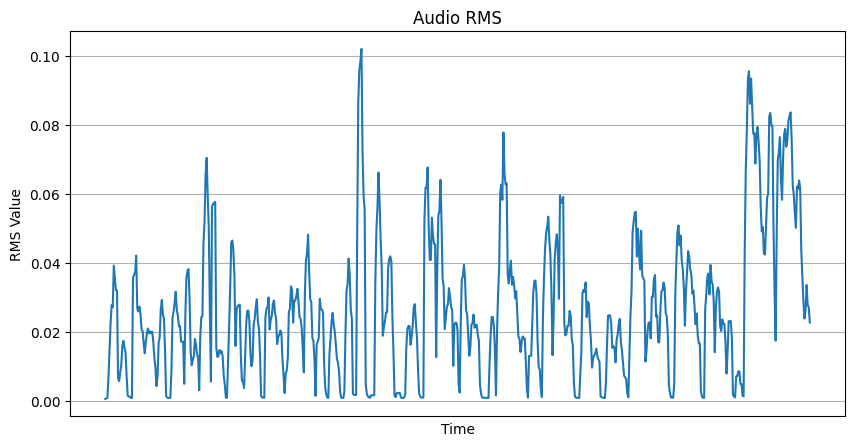

In [11]:
plt.figure(figsize=(10,5))
plt.plot(np.array(range(audio_rms.shape[-1])), audio_rms[0])
plt.title("Audio RMS")
plt.xticks([])
plt.xlabel("Time")
plt.ylabel("RMS Value")
plt.grid(True)
plt.show()

#### 2.3 分割音频

In [12]:
chunks = audio_s.slice(audio_np)

In [13]:
chunks[0][0].shape

(25536,)

In [14]:
for i, chunk in enumerate(chunks):
    # print(i, chunk)
    if isinstance(chunk, list):
        chunk = chunk[0]
    if len(chunk.shape) > 1:
        chunk = chunk.T
    # 保存文件
    soundfile.write(
        "{}/{}_{:02d}.wav".format(output_dir, file_name, i),
        chunk,
        4800,
    )

In [15]:
!ls output

vad_example_00.wav vad_example_03.wav vad_example_06.wav vad_example_09.wav
vad_example_01.wav vad_example_04.wav vad_example_07.wav vad_example_10.wav
vad_example_02.wav vad_example_05.wav vad_example_08.wav vad_example_11.wav
